In [38]:
import importlib
import pandas as pd
import numpy as np
import re
from pathlib import Path

import functions
import functions_Network
importlib.reload(functions)
importlib.reload(functions_Network)
from functions import *
from functions_Network import *

df_1111 = pd.read_csv("AI_Lit_Que_1111.csv")
df_1204 = pd.read_csv("AI_Lit_Que_1204.csv")

# add source/course label
df_1111["course"] = "1111"
df_1204["course"] = "1204"

print(df_1111.shape, df_1204.shape)

df, meta = prepare_dataset("AI_Lit_Que_1111.csv", "AI_Lit_Que_1204.csv")

# EFA for AI literacy
ai_efa_items = [
    "ai_concept_data_bias_scored_num",
    "ai_concept_blackbox_scored_num",
    "ai_concept_input_variation_scored_num",
    "ai_concept_prompt_wording_scored_num",
    "ai_concept_social_ethics_scored_num",
    "ai_ability_training_data_scored_num",
    "ai_ability_explainability_scored_num",
    "ai_ability_input_sensitivity_scored_num",
    "ai_ability_prompting_scored_num",
    "ai_ability_social_ethics_scored_num",
]

df_ai = df.copy()
diag_combined, kmo_items_combined = efa_diagnostics(df_ai, "Combined", ai_efa_items)
fa_combined, d_combined, loadings_combined, variance_combined = fit_efa(
    df=df_ai,
    sample="Combined",
    items=ai_efa_items,
    n_factors=2,
    rotation="oblimin"
)

# EFA for SES
df_ses = add_ses_space_house_variables(df)
ses_efa_items_2dim = [
    "ses_parent1_edu_num",
    "ses_parent2_edu_num",
    "ses_device_access_scored_num",
    "ses_household_income_num",
    "ses_financial_constraint_scored_num",
    "ses_space_per_person",
    "ses_housing_type_ord",
    "ses_internet_quality_scored_num",
    "ses_school_type_ord",
]

diag_ses_combined, kmo_ses_combined = efa_diagnostics(df_ses, "Combined", ses_efa_items_2dim)
fa_ses2, d_ses2, loadings_ses2, variance_ses2 = fit_efa(
    df=df_ses,
    sample="Combined",
    items=ses_efa_items_2dim,
    n_factors=2,
    rotation="oblimin"
)

# combine
df_med = add_mediator_composites(df, mediator_map)
df_analysis = add_ses_ai_factor_scores(
    df_base=df_med,
    ai_df=df,
    ai_items=ai_efa_items,
    ai_fa=fa_combined,
    ses_df=df_ses,
    ses_items=ses_efa_items_2dim,
    ses_fa=fa_ses2
)

(118, 37) (23, 37)


# Partial Correlation 

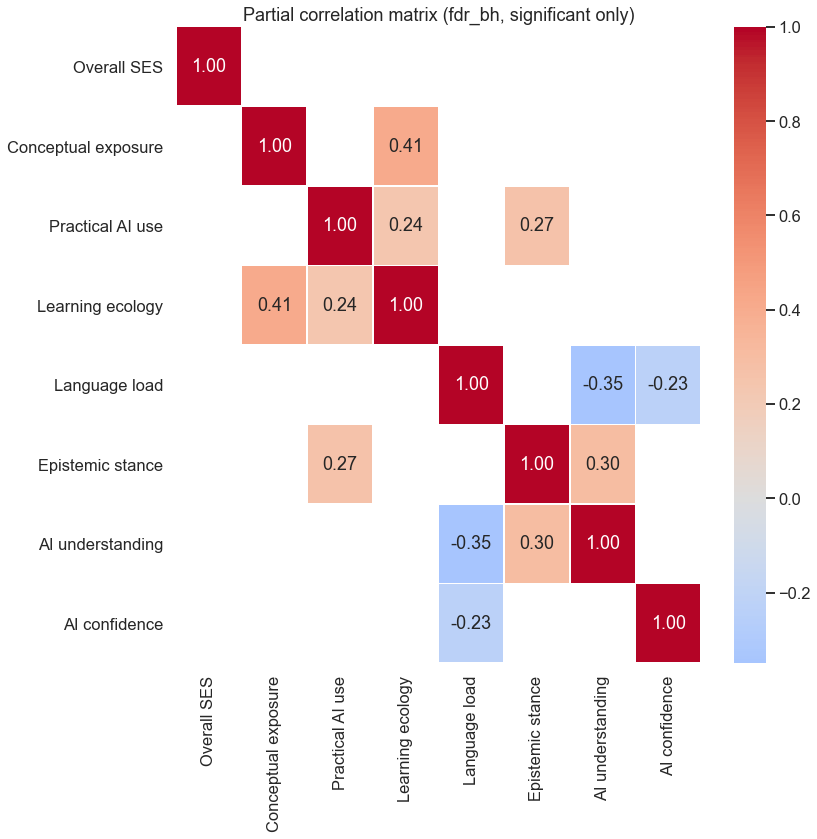

In [32]:
analysis_vars = [
    "ses_index",
    "conceptual_exposure_score",
    "practical_ai_use_score",
    "learning_ecology_score",
    "language_load_score",
    "epistemic_stance_score",
    "ai_factor1_score",
    "ai_factor2_score",
]

pc_obj = partial_corr_matrix(df_analysis, analysis_vars)

# The partial comparison is adjusted for multiple comparisons
#pc_tbl = partial_corr_table(pc_obj, upper_only=True)
# pc_tbl = adjust_partial_corr_p(pc_tbl, method="fdr_bh", alpha=0.05)

pc_obj["estimate"] = pc_obj["estimate"].rename(index=label_map, columns=label_map)
pc_obj["p_value"] = pc_obj["p_value"].rename(index=label_map, columns=label_map)
pc_obj["n"] = pc_obj["n"].rename(index=label_map, columns=label_map)

plot_partial_corr_heatmap(
    pc_obj,
    adjust_method="fdr_bh",
    alpha=0.05,
    sig_only=True,
    figsize=(12, 12)
)


- After controlling for all the other variables in the set, SES has no strong remaining unique pairwise association.


# Network Analysis 

Exam how SES correlated to other variables (Not just by pairwise correlation).

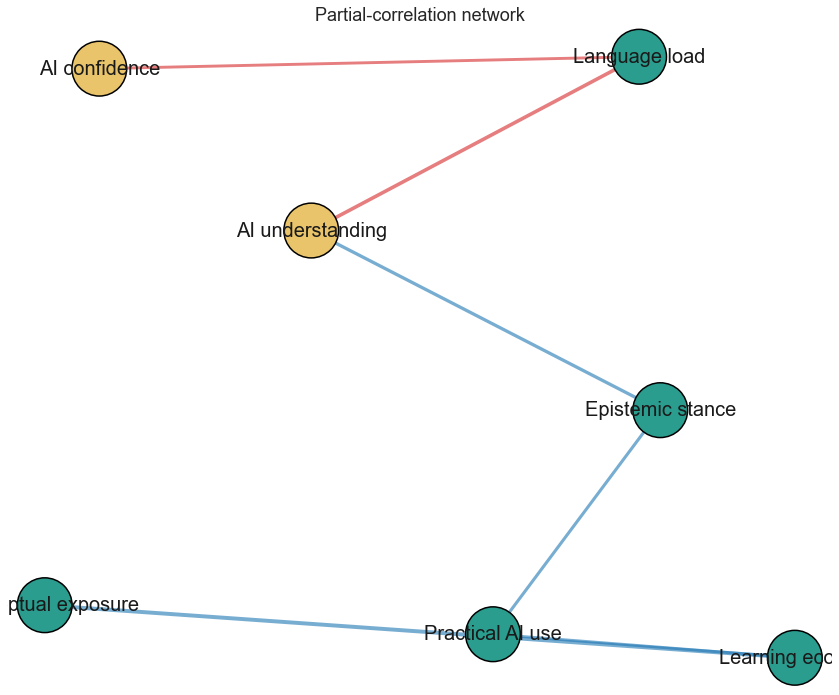

In [40]:
edges = build_network_edges(pc_obj, adjust_method = "fdr_bh", alpha = 0.05, min_abs_r = 0.0)
G = build_network_graph(edges, node_groups = node_groups)
plot_network_graph(G, layout = "spring", figsize = (12, 10))

